<a href="https://colab.research.google.com/github/magmatic654/TelecomX_parte2_Latam/blob/main/TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

In [518]:
import pandas as pd
path = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json'

df = pd.read_json(path)
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformación

## Conociendo el conjunto de datos

Diccionario de datos


- `customerID`: número de identificación único de cada cliente

- `Churn`: si el cliente dejó o no la empresa

- `gender`: género (masculino y femenino)

- `SeniorCitizen`: información sobre si un cliente tiene o no una edad igual o mayor a 65 años

- `Partner`: si el cliente tiene o no una pareja

- `Dependents`: si el cliente tiene o no dependientes

- `tenure`: meses de contrato del cliente

- `PhoneService`: suscripción al servicio telefónico

- `MultipleLines`: suscripción a más de una línea telefónica

- `InternetService`: suscripción a un proveedor de internet

- `OnlineSecurity`: suscripción adicional de seguridad en línea

- `OnlineBackup`: suscripción adicional de respaldo en línea

- `DeviceProtection`: suscripción adicional de protección del dispositivo

- `TechSupport`: suscripción adicional de soporte técnico, menor tiempo de espera

- `StreamingTV`: suscripción de televisión por cable

- `StreamingMovies`: suscripción de streaming de películas

- `Contract`: tipo de contrato

- `PaperlessBilling`: si el cliente prefiere recibir la factura en línea

- `PaymentMethod`: forma de pago

- `Charges.Monthly`: total de todos los servicios del cliente por mes

- `Charges.Total`: total gastado por el cliente



In [519]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


Nuestras columnas no corresponden correctamente a lo solicitado, pues aun se encuentran sin normalizar los JSON de las columnas

## Comprobación de incoherencias en los datos

### Tratamiento

#### Columnas con JSON

In [520]:
records = df.to_dict(orient='records')
df = pd.json_normalize(records, )
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


Simplificamos el nombre de las columnas reemplazando su primer nivel antes del punto por un espacio en blanco

In [521]:
df.columns = df.columns.str.replace(r'^[^.]*\.', '', regex=True)
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#### Valores Nulos


In [522]:
df.isnull().sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


#### No duplicados

In [523]:
print('Numero de Clientes:', df.shape[0])
print('Numero de Clientes unicos:', len(pd.unique(df['customerID'])))

Numero de Clientes: 7267
Numero de Clientes unicos: 7267


#### Valores Faltantes

In [524]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [525]:
for col in df.columns[1:19]:
  print(f'\n{col}: {pd.unique(df[col])}')


Churn: ['No' 'Yes' '']

gender: ['Female' 'Male']

SeniorCitizen: [0 1]

Partner: ['Yes' 'No']

Dependents: ['Yes' 'No']

tenure: [ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 11 37 49 66
 67 20 43 59 12 27  2 25 29 14 35 64 39 40  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 51 31 36 17 18 38 42
  0]

PhoneService: ['Yes' 'No']

MultipleLines: ['No' 'Yes' 'No phone service']

InternetService: ['DSL' 'Fiber optic' 'No']

OnlineSecurity: ['No' 'Yes' 'No internet service']

OnlineBackup: ['Yes' 'No' 'No internet service']

DeviceProtection: ['No' 'Yes' 'No internet service']

TechSupport: ['Yes' 'No' 'No internet service']

StreamingTV: ['Yes' 'No' 'No internet service']

StreamingMovies: ['No' 'Yes' 'No internet service']

Contract: ['One year' 'Month-to-month' 'Two year']

PaperlessBilling: ['Yes' 'No']

PaymentMethod: ['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']


Se repiten valores para escribir "No" en distintas columnas, pudiendo ser alguna de las siguientes:
- `"No phone service"`
- `"No internet service"`
- `""`

Sera mejor pasarlos a booleanos para simplificar, por lo que primero normalizamos "Yes" y "No"

Tambien se detecta que hay filas sin estar etiquetadas en la columna `Churn`: `""`

In [526]:
import numpy as np

# 1. Convertimos espacios vacíos o puros espacios en blanco a NaN
df['Churn'] = df['Churn'].replace(r'^\s*$', np.nan, regex=True)

# 2. Ahora sí, eliminamos
df = df.dropna(subset=['Churn'])
df['Churn'].unique()

array(['No', 'Yes'], dtype=object)

In [527]:
# Diccionario de Regex
# (?i)  -> Ignora mayúsculas/minúsculas (case-insensitive)
# ^     -> Indica que debe empezar con esa palabra
# .* -> Coincide con cualquier carácter que venga después
mapeo_regex = {
    r'(?i)^Yes.*': 0,
    r'(?i)^No.*': 1
}

# Estandarizar todas las columnas de yes y
for col in df.columns:
  df[col] = df[col].replace(mapeo_regex, regex=True)


/tmp/ipykernel_458/2649228859.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace(mapeo_regex, regex=True)


#### Columna Cuenta Diaria

In [528]:
df['Cuentas_Diarias'] = round(df['Charges.Monthly'] / 30, 2)
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,1,Female,0,0,0,9,0,1,DSL,1,0,1,0,0,1,One year,0,Mailed check,65.6,593.3,2.19
1,0003-MKNFE,1,Male,0,1,1,9,0,0,DSL,1,1,1,1,1,0,Month-to-month,1,Mailed check,59.9,542.4,2.00
2,0004-TLHLJ,0,Male,0,1,1,4,0,1,Fiber optic,1,1,0,1,1,1,Month-to-month,0,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,0,Male,1,0,1,13,0,1,Fiber optic,1,0,0,1,0,0,Month-to-month,0,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,0,Female,1,0,1,3,0,1,Fiber optic,1,1,1,0,0,1,Month-to-month,0,Mailed check,83.9,267.4,2.80


#📊 Carga y análisis

In [529]:
import pandas as pd
import matplotlib.pyplot as plt
import math

In [530]:
df.describe()

,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,Charges.Monthly,Cuentas_Diarias
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.734630,0.162147,0.516967,0.700412,32.371149,0.096834,0.578163,0.713332,0.655119,0.656112,0.709783,0.615647,0.612097,0.407781,64.761692,2.158675
std,0.441561,0.368612,0.499748,0.458110,24.559481,0.295752,0.493888,0.452237,0.475363,0.475038,0.453895,0.486477,0.487307,0.491457,30.090047,1.003088
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.610000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.500000,1.180000
50%,1.000000,0.000000,1.000000,1.000000,29.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,70.350000,2.340000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.850000,2.990000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,118.750000,3.960000


Distribucion categorica

Ranking de Impacto en Churn:
             columna    impacto
13          Contract  39.877819
6    InternetService  34.487785
15     PaymentMethod  30.042311
1      SeniorCitizen  18.075092
14  PaperlessBilling  17.235009
7     OnlineSecurity  16.718424
10       TechSupport  16.019897
3         Dependents  15.828904
2            Partner  13.293076
8       OnlineBackup   7.640591
9   DeviceProtection   6.149743
11       StreamingTV   5.739008
12   StreamingMovies   5.561941


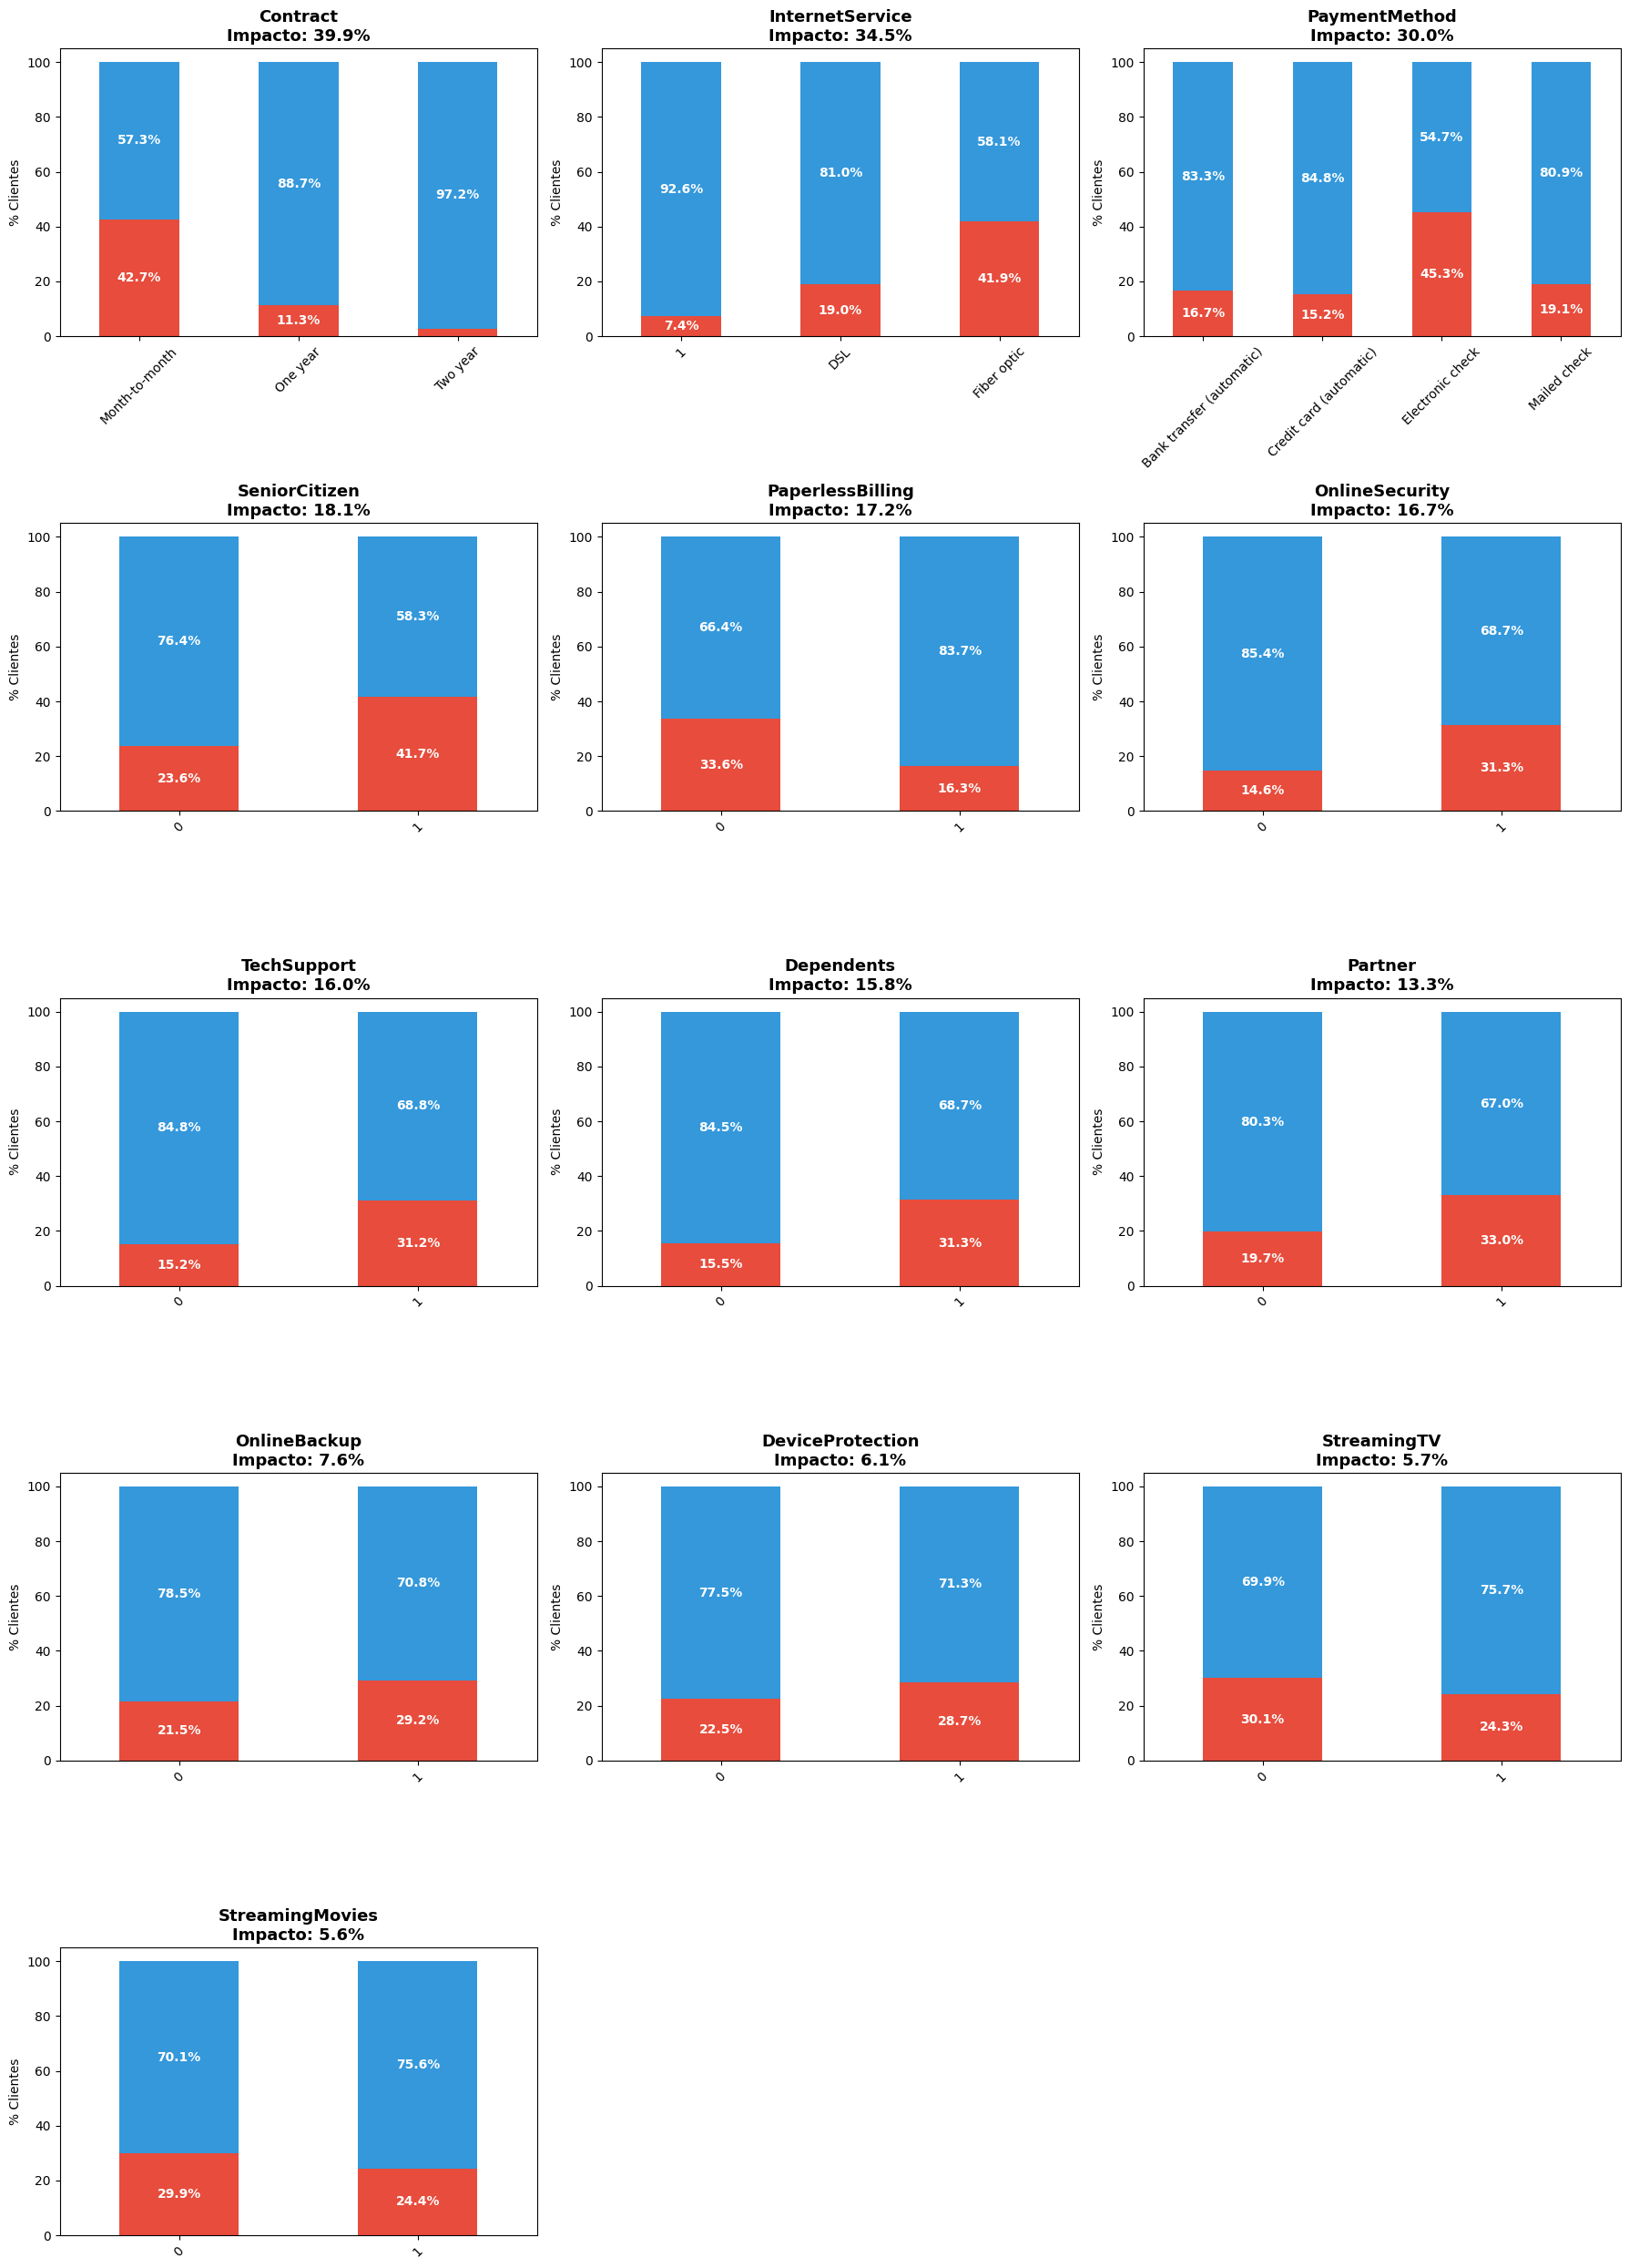

In [531]:
# 1. Definir columnas y excluir 'tenure'
cols_to_check = [col for col in df.columns[2:19] if col not in ['tenure', 'ternure']]
impactos = []

# 2. Calcular el impacto para cada columna
for col in cols_to_check:
    # Generamos la tabla de contingencia normalizada
    ct = pd.crosstab(df[col], df['Churn'], normalize='index') * 100

    # Verificamos que existan datos de Churn (True)
    if 1 in ct.columns:
        # Impacto = Diferencia entre el máximo y mínimo porcentaje de Churn en las categorías
        diff = ct[1].max() - ct[1].min()
        impactos.append({'columna': col, 'impacto': diff})

# 3. Guardar y Organizar de mayor a menor
df_impactos = pd.DataFrame(impactos).sort_values(by='impacto', ascending=False)

# Filtramos solo las que tienen impacto > 5%
df_filtrado = df_impactos[df_impactos['impacto'] > 5]

print("Ranking de Impacto en Churn:")
print(df_filtrado)

# 4. Configurar la cuadrícula con las columnas ordenadas
cols_ordenadas = df_filtrado['columna'].tolist()
n_cols = 3
n_rows = math.ceil(len(cols_ordenadas) / n_cols)

if len(cols_ordenadas) > 0:
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 5))
    axes = axes.flatten()

    for i, col in enumerate(cols_ordenadas):
        # Obtener el valor del impacto para el título
        val_impacto = df_filtrado[df_filtrado['columna'] == col]['impacto'].values[0]

        reporte_pct = pd.crosstab(df[col], df['Churn'], normalize='index') * 100

        # Graficar (Ordenando también las barras para que sean consistentes)
        reporte_pct.plot(kind='bar', stacked=True, ax=axes[i], color=['#e74c3c', '#3498db'], legend=False)

        axes[i].set_title(f'{col}\nImpacto: {val_impacto:.1f}%', fontsize=13, fontweight='bold')
        axes[i].set_ylabel('% Clientes')
        axes[i].set_xlabel('')
        axes[i].tick_params(axis='x', rotation=45)

        # Añadir etiquetas
        for p in axes[i].patches:
            h = p.get_height()
            if h > 5:
                axes[i].annotate(f'{h:.1f}%', (p.get_x() + p.get_width()/2., p.get_y() + h/2.),
                                 ha='center', va='center', color='white', fontsize=10, fontweight='bold')

    # Ocultar cuadros vacíos
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Ninguna columna superó el umbral del 5% de impacto.")

Conteo de evasion por variables numericas

In [532]:
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,1,Female,0,0,0,9,0,1,DSL,1,0,1,0,0,1,One year,0,Mailed check,65.6,593.3,2.19
1,0003-MKNFE,1,Male,0,1,1,9,0,0,DSL,1,1,1,1,1,0,Month-to-month,1,Mailed check,59.9,542.4,2.00
2,0004-TLHLJ,0,Male,0,1,1,4,0,1,Fiber optic,1,1,0,1,1,1,Month-to-month,0,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,0,Male,1,0,1,13,0,1,Fiber optic,1,0,0,1,0,0,Month-to-month,0,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,0,Female,1,0,1,3,0,1,Fiber optic,1,1,1,0,0,1,Month-to-month,0,Mailed check,83.9,267.4,2.80


#📄Informe final

In [533]:
print("Unique values in 'Charges.Total':", df['Charges.Total'].unique())
print("Number of non-numeric values in 'Charges.Total':", pd.to_numeric(df['Charges.Total'], errors='coerce').isnull().sum())

Unique values in 'Charges.Total': ['593.3' '542.4' '280.85' ... '742.9' '4627.65' '3707.6']
Number of non-numeric values in 'Charges.Total': 11


In [534]:
df['Charges.Total'] = pd.to_numeric(df['Charges.Total'], errors='coerce')
df['Charges.Total'] = df['Charges.Total'].fillna(df['Charges.Total'].median())
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,1,Female,0,0,0,9,0,1,DSL,1,0,1,0,0,1,One year,0,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,1,Male,0,1,1,9,0,0,DSL,1,1,1,1,1,0,Month-to-month,1,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,0,Male,0,1,1,4,0,1,Fiber optic,1,1,0,1,1,1,Month-to-month,0,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,0,Male,1,0,1,13,0,1,Fiber optic,1,0,0,1,0,0,Month-to-month,0,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,0,Female,1,0,1,3,0,1,Fiber optic,1,1,1,0,0,1,Month-to-month,0,Mailed check,83.9,267.40,2.80


## Bin 'Charges.Total' y Conversión

Crear 5 grupos (bins) para las columnas 'Charges.Total' y 'tenure'.


In [535]:
df['Charges.Total_Bins'] = pd.qcut(df['Charges.Total'], q=5, labels=False)
df['tenure_Bins'] = pd.qcut(df['tenure'], q=5, labels=False)
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias,Charges.Total_Bins,tenure_Bins
0,0002-ORFBO,1,Female,0,0,0,9,0,1,DSL,1,0,1,0,0,1,One year,0,Mailed check,65.6,593.30,2.19,1,1
1,0003-MKNFE,1,Male,0,1,1,9,0,0,DSL,1,1,1,1,1,0,Month-to-month,1,Mailed check,59.9,542.40,2.00,1,1
2,0004-TLHLJ,0,Male,0,1,1,4,0,1,Fiber optic,1,1,0,1,1,1,Month-to-month,0,Electronic check,73.9,280.85,2.46,1,0
3,0011-IGKFF,0,Male,1,0,1,13,0,1,Fiber optic,1,0,0,1,0,0,Month-to-month,0,Electronic check,98.0,1237.85,3.27,2,1
4,0013-EXCHZ,0,Female,1,0,1,3,0,1,Fiber optic,1,1,1,0,0,1,Month-to-month,0,Mailed check,83.9,267.40,2.80,1,0


In [536]:
churn_by_charges_bins = pd.crosstab(df['Charges.Total_Bins'], df['Churn'], normalize='index') * 100
churn_by_tenure_bins = pd.crosstab(df['tenure_Bins'], df['Churn'], normalize='index') * 100

print("Churn Rate by Charges.Total Bins:")
print(churn_by_charges_bins)

print("\nChurn Rate by Tenure Bins:")
print(churn_by_tenure_bins)

Churn Rate by Charges.Total Bins:
Churn                       0          1
Charges.Total_Bins                      
0                   45.990064  54.009936
1                   28.906250  71.093750
2                   20.652945  79.347055
3                   23.011364  76.988636
4                   14.123492  85.876508

Churn Rate by Tenure Bins:
Churn                0          1
tenure_Bins                      
0            52.937205  47.062795
1            33.428776  66.571224
2            22.372159  77.627841
3            15.555556  84.444444
4             6.609808  93.390192


## Análisis y Visualización de la Tasa de Abandono por Cargos Totales

### Subtask:
Visualizar la tasa de abandono por 'Charges.Total' binned.


**Reasoning**:
To visualize the churn rate by 'Charges.Total_Bins', I will create a stacked bar chart using the 'churn_by_charges_bins' DataFrame, applying the specified colors, title, and y-axis label.



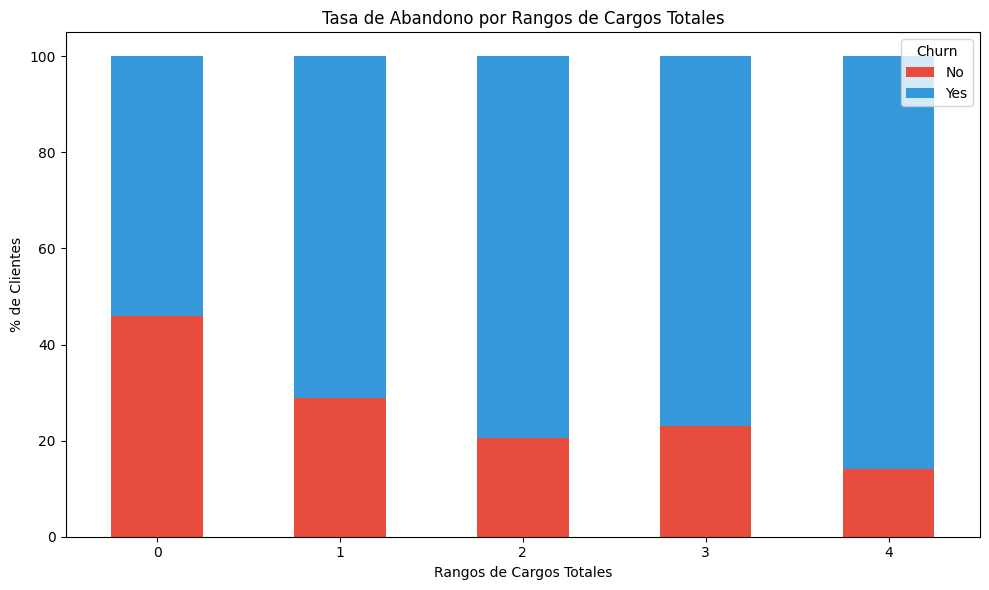

In [537]:
churn_by_charges_bins.plot(kind='bar', stacked=True, color=['#e74c3c', '#3498db'], figsize=(10, 6))
plt.title('Tasa de Abandono por Rangos de Cargos Totales')
plt.ylabel('% de Clientes')
plt.xlabel('Rangos de Cargos Totales')
plt.xticks(rotation=0)
plt.legend(title='Churn', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

**Reasoning**:
To visualize the churn rate by 'tenure_Bins', I will create a stacked bar chart using the 'churn_by_tenure_bins' DataFrame, applying similar colors, title, and y-axis label for consistency.



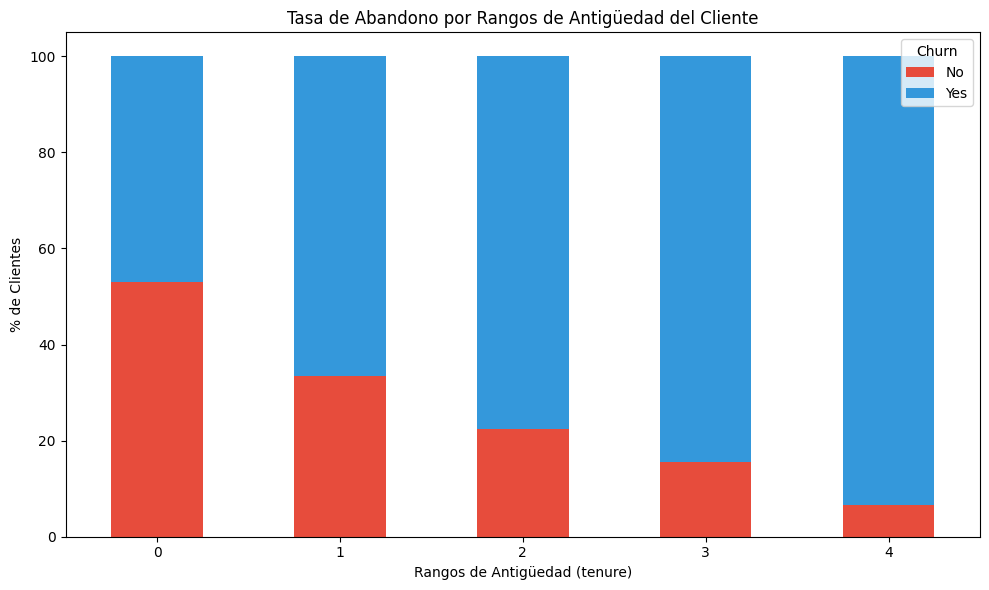

In [538]:
churn_by_tenure_bins.plot(kind='bar', stacked=True, color=['#e74c3c', '#3498db'], figsize=(10, 6))
plt.title('Tasa de Abandono por Rangos de Antigüedad del Cliente')
plt.ylabel('% de Clientes')
plt.xlabel('Rangos de Antigüedad (tenure)')
plt.xticks(rotation=0)
plt.legend(title='Churn', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

# 🛠️ Preparación de los Datos

## **Eliminación de Columnas Irrelevantes**

In [539]:
pd.set_option('display.max_columns', None)
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias,Charges.Total_Bins,tenure_Bins
0,0002-ORFBO,1,Female,0,0,0,9,0,1,DSL,1,0,1,0,0,1,One year,0,Mailed check,65.6,593.30,2.19,1,1
1,0003-MKNFE,1,Male,0,1,1,9,0,0,DSL,1,1,1,1,1,0,Month-to-month,1,Mailed check,59.9,542.40,2.00,1,1
2,0004-TLHLJ,0,Male,0,1,1,4,0,1,Fiber optic,1,1,0,1,1,1,Month-to-month,0,Electronic check,73.9,280.85,2.46,1,0
3,0011-IGKFF,0,Male,1,0,1,13,0,1,Fiber optic,1,0,0,1,0,0,Month-to-month,0,Electronic check,98.0,1237.85,3.27,2,1
4,0013-EXCHZ,0,Female,1,0,1,3,0,1,Fiber optic,1,1,1,0,0,1,Month-to-month,0,Mailed check,83.9,267.40,2.80,1,0


In [540]:
df.columns

Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly', 'Charges.Total',
       'Cuentas_Diarias', 'Charges.Total_Bins', 'tenure_Bins'],
      dtype='object')

In [541]:
df[['Charges.Monthly', 'Charges.Total', 'Cuentas_Diarias']].corr()

,Charges.Monthly,Charges.Total,Cuentas_Diarias
Charges.Monthly,1.000000,0.650864,0.999996
Charges.Total,0.650864,1.000000,0.650881
Cuentas_Diarias,0.999996,0.650881,1.000000


In [542]:
df[['Charges.Total', 'tenure']].corr()

,Charges.Total,tenure
Charges.Total,1.000000,0.825464
tenure,0.825464,1.000000


Los **cargos mensuales** (`Charges.Monthly`) y las **cuentas diarias** (`Cuentas_Diarias`) tienen una correlacion positiva fuerte, por lo que es conveniente solo dejar una de ellas.

Pasa lo mismo con la `Charges.Total` y `tenure`

In [543]:
df = df.drop(columns=['customerID', 'Charges.Monthly', 'Charges.Total', 'tenure_Bins', 'Charges.Total_Bins'], axis=1)
df.head()

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Cuentas_Diarias
0,1,Female,0,0,0,9,0,1,DSL,1,0,1,0,0,1,One year,0,Mailed check,2.19
1,1,Male,0,1,1,9,0,0,DSL,1,1,1,1,1,0,Month-to-month,1,Mailed check,2.00
2,0,Male,0,1,1,4,0,1,Fiber optic,1,1,0,1,1,1,Month-to-month,0,Electronic check,2.46
3,0,Male,1,0,1,13,0,1,Fiber optic,1,0,0,1,0,0,Month-to-month,0,Electronic check,3.27
4,0,Female,1,0,1,3,0,1,Fiber optic,1,1,1,0,0,1,Month-to-month,0,Mailed check,2.80


## **Encoding**

In [544]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Churn             7043 non-null   int64  
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   int64  
 4   Dependents        7043 non-null   int64  
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   int64  
 7   MultipleLines     7043 non-null   int64  
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   int64  
 10  OnlineBackup      7043 non-null   int64  
 11  DeviceProtection  7043 non-null   int64  
 12  TechSupport       7043 non-null   int64  
 13  StreamingTV       7043 non-null   int64  
 14  StreamingMovies   7043 non-null   int64  
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   int64  
 17  

In [545]:
df_encoded = pd.get_dummies(df, dtype=int)
df_encoded

,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,Cuentas_Diarias,gender_Female,gender_Male,InternetService_1,InternetService_DSL,InternetService_Fiber optic,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,0,0,9,0,1,1,0,1,0,0,1,0,2.19,1,0,0,1,0,0,1,0,0,0,0,1
1,1,0,1,1,9,0,0,1,1,1,1,1,0,1,2.00,0,1,0,1,0,1,0,0,0,0,0,1
2,0,0,1,1,4,0,1,1,1,0,1,1,1,0,2.46,0,1,0,0,1,1,0,0,0,0,1,0
3,0,1,0,1,13,0,1,1,0,0,1,0,0,0,3.27,0,1,0,0,1,1,0,0,0,0,1,0
4,0,1,0,1,3,0,1,1,1,1,0,0,1,0,2.80,1,0,0,0,1,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,1,0,1,1,13,0,1,0,1,1,0,1,1,1,1.84,1,0,0,1,0,0,1,0,0,0,0,1
7263,0,0,0,1,22,0,0,1,1,1,1,1,0,0,2.84,0,1,0,0,1,1,0,0,0,0,1,0
7264,1,0,1,1,2,0,1,1,0,1,1,1,1,0,1.68,0,1,0,1,0,1,0,0,0,0,0,1
7265,1,0,0,0,67,0,1,0,1,0,0,1,0,1,2.26,0,1,0,1,0,0,0,1,0,0,0,1


## **Verificación de la Proporción de Cancelación** (Churn)

In [546]:
df['Churn'].value_counts()

,count
Churn,
1,5174
0,1869


In [547]:
df['Churn'].value_counts(normalize=True)

,proportion
Churn,
1,0.73463
0,0.26537


La mayoria de personas han dejado la empresa, representando el 73% del total.

Churn: 'Si' -> 73%, 'No' -> 26%

Por lo que podemos considerar realizar un balanceo con Oversample o UnderSample

## **Balanceo de Clases**

### OverSampling

In [548]:
from imblearn.over_sampling import SMOTE

In [549]:
X = df_encoded.drop(columns='Churn', axis=1)
y = df_encoded['Churn']

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)

In [550]:
y_res.value_counts()

,count
Churn,
1,5174
0,5174


In [551]:
y_res.value_counts(normalize=True)

,proportion
Churn,
1,0.5
0,0.5


In [552]:
df = pd.concat([X_res, y_res], axis=1)
df.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,Cuentas_Diarias,gender_Female,gender_Male,InternetService_1,InternetService_DSL,InternetService_Fiber optic,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn
0,0,0,0,9,0,1,1,0,1,0,0,1,0,2.19,1,0,0,1,0,0,1,0,0,0,0,1,1
1,0,1,1,9,0,0,1,1,1,1,1,0,1,2.00,0,1,0,1,0,1,0,0,0,0,0,1,1
2,0,1,1,4,0,1,1,1,0,1,1,1,0,2.46,0,1,0,0,1,1,0,0,0,0,1,0,0
3,1,0,1,13,0,1,1,0,0,1,0,0,0,3.27,0,1,0,0,1,1,0,0,0,0,1,0,0
4,1,0,1,3,0,1,1,1,1,0,0,1,0,2.80,1,0,0,0,1,1,0,0,0,0,0,1,0


## **Normalización o Estandarización**

En este caso, es necesario realizar la normalizacion de datos a para un rango entre 0 y 1 **{x|x >= 0 & x <= 1}** debido a que voy a utilizar el modelo **KNN**. Tambien utilizare el modelo **Decision Tree** y **Random Forest** (para estos no es necesaria la normalizacion)

In [553]:
import seaborn as sns

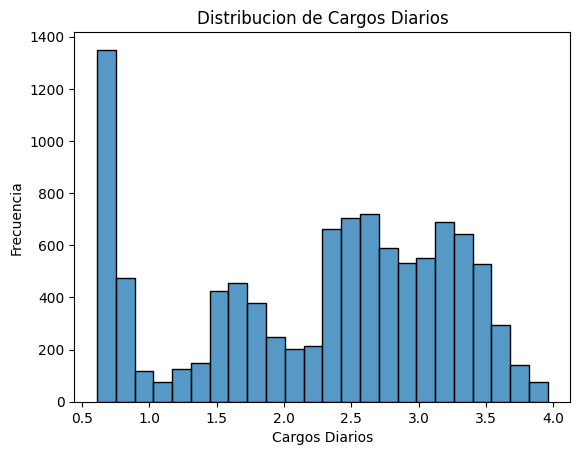

In [554]:
sns.histplot(df, x='Cuentas_Diarias')
plt.title('Distribucion de Cargos Diarios')
plt.xlabel('Cargos Diarios')
plt.ylabel('Frecuencia')
plt.show()

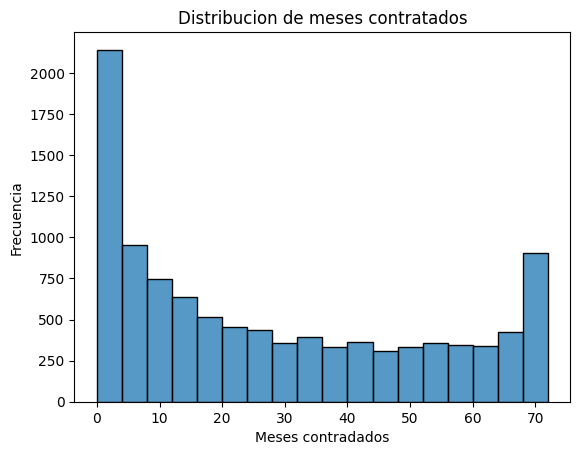

In [555]:
sns.histplot(df, x='tenure')
plt.title('Distribucion de meses contratados')
plt.xlabel('Meses contradados')
plt.ylabel('Frecuencia')
plt.show()

In [556]:
# Normalizando Datos
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_normalizado = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

In [557]:
df_normalizado.head(2)

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,Cuentas_Diarias,gender_Female,gender_Male,InternetService_1,InternetService_DSL,InternetService_Fiber optic,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn
0,0.0,0.0,0.0,0.125,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.471642,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
1,0.0,1.0,1.0,0.125,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.414925,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0


# 🎯 Correlación y Selección de Variables

In [558]:
corr_abs = df.corr()['Churn'].abs().sort_values(ascending=False)
corr_abs

,Churn
Churn,1.000000
Contract_Month-to-month,0.471307
tenure,0.408359
Contract_Two year,0.406464
InternetService_Fiber optic,0.339399
PaymentMethod_Electronic check,0.311499
PaperlessBilling,0.307865
InternetService_1,0.297312
Contract_One year,0.263681
Cuentas_Diarias,0.235059


In [559]:
df = df[corr_abs.index[:21]]

## **Análisis Dirigido**

In [560]:
df.columns

Index(['Churn', 'Contract_Month-to-month', 'tenure', 'Contract_Two year',
       'InternetService_Fiber optic', 'PaymentMethod_Electronic check',
       'PaperlessBilling', 'InternetService_1', 'Contract_One year',
       'Cuentas_Diarias', 'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Bank transfer (automatic)', 'InternetService_DSL',
       'OnlineSecurity', 'Dependents', 'PaymentMethod_Mailed check',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Partner',
       'MultipleLines'],
      dtype='object')

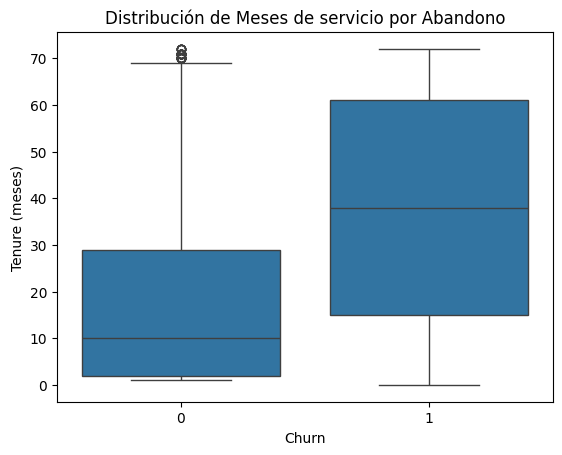

In [561]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Distribución de Meses de servicio por Abandono')
plt.xlabel('Churn')
plt.ylabel('Tenure (meses)')
plt.show()

**Reasoning**:
The subtask is to visualize the distribution of `Cuentas_Diarias` for churned and non-churned customers using a boxplot. This will provide insights into how daily charges might relate to customer churn.



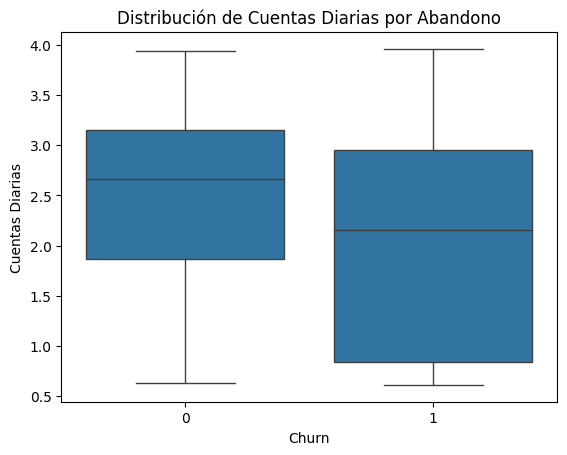

In [562]:
sns.boxplot(x='Churn', y='Cuentas_Diarias', data=df)
plt.title('Distribución de Cuentas Diarias por Abandono')
plt.xlabel('Churn')
plt.ylabel('Cuentas Diarias')
plt.show()

## Análisis de la Distribución de Churn por Variables Numéricas

### Observaciones Clave:

**Tenure (Antigüedad del Cliente):**
- **Clientes que NO abandonaron (Churn = 1):** La distribución de `tenure` para estos clientes muestra una mediana y un rango intercuartílico significativamente más altos. Esto indica que los clientes con mayor antigüedad (más meses de contrato) son menos propensos a abandonar el servicio.
- **Clientes que SÍ abandonaron (Churn = 0):** Por el contrario, los clientes que abandonaron tienen una mediana de `tenure` mucho menor y una distribución sesgada hacia los valores más bajos. Esto sugiere que los clientes con poca antigüedad son más propensos a la deserción.

**Cuentas_Diarias (Cargos Diarios):**
- **Clientes que NO abandonaron (Churn = 1):** La distribución de `Cuentas_Diarias` para estos clientes tiende a tener una mediana y un rango intercuartílico más bajos, lo que implica que los clientes con menores cargos diarios son más estables.
- **Clientes que SÍ abandonaron (Churn = 0):** Se observa que los clientes que abandonaron presentan una mediana de `Cuentas_Diarias` más alta, con una dispersión que indica que los cargos diarios más elevados pueden estar asociados con una mayor probabilidad de churn.

**Resumen:**
Los box plots revelan una clara relación entre estas variables numéricas y la tasa de abandono. Los clientes con **menor antigüedad** en el servicio (`tenure` bajo) y **mayores cargos diarios** (`Cuentas_Diarias` alta) son significativamente más propensos a abandonar. Esto subraya la importancia de la fidelización temprana y la gestión de los costos percibidos por el cliente como factores clave para reducir la tasa de churn.

## **Separación de Datos**

In [563]:
from sklearn.model_selection import train_test_split

In [564]:
X = df.drop(columns=['Churn'], axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## **Creación de Modelos**

In [565]:
from sklearn.neighbors import KNeighborsClassifier

In [566]:
modelo_knn = KNeighborsClassifier()
modelo_knn.fit(X_train, y_train)

KNeighborsClassifier()

In [567]:
from sklearn.tree import DecisionTreeClassifier

In [568]:
modelo_tree = DecisionTreeClassifier(max_depth=10)
modelo_tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10)

In [569]:
from sklearn.ensemble import RandomForestClassifier

In [570]:
modelo_forest = RandomForestClassifier(max_depth=10)
modelo_forest.fit(X_train, y_train)

RandomForestClassifier(max_depth=10)

## **Evaluación de los Modelos**

### Evaluacion con Datos de Entrenamiento

In [571]:
from sklearn.metrics import classification_report

In [572]:
modelos = [('KNN', modelo_knn), ('Arbol', modelo_tree), ('Bosque', modelo_forest)]

for item in modelos:
  y_previsto = item[1].predict(X_train)

  print('-'*38 + f' Evaluacion de modelo {item[0]}' + '-'*38)
  print(classification_report(y_train, y_previsto))
  print('\n')

-------------------------------------- Evaluacion de modelo KNN--------------------------------------
              precision    recall  f1-score   support

           0       0.83      0.94      0.88      3657
           1       0.93      0.80      0.86      3586

    accuracy                           0.87      7243
   macro avg       0.88      0.87      0.87      7243
weighted avg       0.88      0.87      0.87      7243



-------------------------------------- Evaluacion de modelo Arbol--------------------------------------
              precision    recall  f1-score   support

           0       0.85      0.91      0.88      3657
           1       0.90      0.84      0.87      3586

    accuracy                           0.88      7243
   macro avg       0.88      0.88      0.88      7243
weighted avg       0.88      0.88      0.88      7243



-------------------------------------- Evaluacion de modelo Bosque--------------------------------------
              precision    reca

### Evaluacion con Datos de Prueba

In [573]:
for item in modelos:
  y_previsto = item[1].predict(X_test)

  print('-'*38 + f' Evaluacion de modelo {item[0]}' + '-'*38)
  print(classification_report(y_test, y_previsto))
  print('\n')

-------------------------------------- Evaluacion de modelo KNN--------------------------------------
              precision    recall  f1-score   support

           0       0.75      0.90      0.82      1517
           1       0.88      0.72      0.79      1588

    accuracy                           0.80      3105
   macro avg       0.82      0.81      0.80      3105
weighted avg       0.82      0.80      0.80      3105



-------------------------------------- Evaluacion de modelo Arbol--------------------------------------
              precision    recall  f1-score   support

           0       0.77      0.85      0.81      1517
           1       0.84      0.76      0.80      1588

    accuracy                           0.80      3105
   macro avg       0.81      0.80      0.80      3105
weighted avg       0.81      0.80      0.80      3105



-------------------------------------- Evaluacion de modelo Bosque--------------------------------------
              precision    reca

## **Análisis de la Importancia de las Variables**

In [578]:
# 1. Acceder al modelo Random Forest entrenado (modelo_forest)
# 2. Extraer las importancias de las características
importancias = modelo_forest.feature_importances_

# 3. Crear DataFrame relacionando nombres de columnas y valores de importancia
rf_importancia_df = pd.DataFrame({
    'Caracteristica': X_train.columns,
    'Importancia': importancias
})

# 4. Ordenar de forma descendente
rf_importancia_df = rf_importancia_df.sort_values(by='Importancia', ascending=False)

# 5. Seleccionar las 10 características principales para comparación posterior
top_10_rf = rf_importancia_df.head(10)

# 6. Mostrar el top 10 resultante
print("Top 10 Variables identificadas por Random Forest (Reducción de Impureza):")
print(top_10_rf)

Top 10 Variables identificadas por Random Forest (Reducción de Impureza):
                    Caracteristica  Importancia
1                           tenure     0.184850
0          Contract_Month-to-month     0.172381
8                  Cuentas_Diarias     0.121166
2                Contract_Two year     0.110907
7                Contract_One year     0.056412
5                 PaperlessBilling     0.052593
3      InternetService_Fiber optic     0.044190
6                InternetService_1     0.033810
11             InternetService_DSL     0.031274
4   PaymentMethod_Electronic check     0.028750


## Conclusion

## Informe de Factores Determinantes de Churn

Basado en el análisis de importancia de variables del modelo Random Forest (`rf_importancia_df`), se ha identificado que **'tenure' (antigüedad)**, **'Contract_Month-to-month' (contrato mensual)** y **'Cuentas_Diarias' (cargos diarios)** son los tres predictores más críticos para determinar el abandono de clientes.

El modelo selecciona estas variables utilizando el criterio de **'Reducción de Impureza'**. Este concepto técnico significa que, durante el entrenamiento, el algoritmo identifica que estas características ofrecen las mejores particiones para separar a los clientes que se van de los que se quedan. Al realizar cortes basados en estos valores, el modelo logra crear nodos hijos más 'puros' u homogéneos, maximizando la capacidad de clasificación y reduciendo la incertidumbre en cada paso.

Este hallazgo técnico coincide plenamente con nuestras visualizaciones anteriores. Por ejemplo, observamos que el tipo de contrato tiene un impacto masivo en la tasa de abandono: los contratos **'Month-to-month'** presentaron una diferencia de impacto de aproximadamente el **40%** en comparación con los contratos a largo plazo, consolidándose como la variable con mayor influencia directa en la decisión de deserción del cliente.

## Propuesta de Estrategias de Retención

Basado en el análisis de datos realizado, se proponen las siguientes estrategias para reducir la tasa de abandono (Churn):

### 1. Incentivos de Migración de Contrato (Target: Contract Type)
*   **Hallazgo:** El impacto de los contratos 'Month-to-month' en el churn es cercano al 40%, siendo el factor más crítico.
*   **Estrategia:** Implementar una campaña de conversión para migrar clientes de planes mensuales a contratos de uno o dos años.
*   **Acción:** Ofrecer descuentos escalonados (ej. 15% de descuento en el primer año) o servicios de valor agregado gratuitos (como suscripciones a streaming o aumento de velocidad de internet) para quienes acepten el compromiso anual, reduciendo así la volatilidad del ingreso.

### 2. Programa de Fidelización Temprana (Target: Tenure)
*   **Hallazgo:** Los clientes con baja antigüedad ('tenure' < 6 meses) presentan la mayor probabilidad de deserción.
*   **Estrategia:** Crear un 'Welcome Journey' (Viaje de Bienvenida) diseñado para los primeros 6 meses.
*   **Acción:** Implementar puntos de contacto proactivos en los meses 1, 3 y 5. Ofrecer un 'Bono de Lealtad' que se activa al cumplir el séptimo mes, aumentando el costo de oportunidad de cambiar de proveedor durante el periodo crítico de adaptación.

### 3. Optimización de Costos para Clientes de Alto Valor (Target: Cuentas_Diarias)
*   **Hallazgo:** Los clientes con cargos diarios elevados ('Cuentas_Diarias' alta) son más propensos a abandonar, posiblemente por una percepción de bajo valor/costo.
*   **Estrategia:** Sistema de monitoreo y re-empaquetamiento proactivo.
*   **Acción:** Identificar automáticamente a clientes en el decil superior de cargos diarios para ofrecerles 'Planes Familiares' o 'Bundles' (paquetes) que consoliden servicios. El objetivo es optimizar su gasto mensual antes de que el cliente busque activamente una alternativa más económica en la competencia.